# Bayesian Mean Estimation with Metropolis–Hastings

This notebook uses the **`bme_homodyne`** package 
The workflow is:

1. define a truncated CV target state,
2. simulate homodyne measurements,
3. bin the data,
4. precompute the quadrature-bin effects,
5. evaluate the likelihood,
6. run Metropolis–Hastings Bayesian mean estimation,
7. inspect convergence and MH diagnostics,
8. plot the reconstructed Wigner function.



In [ ]:


import numpy as np
import matplotlib.pyplot as plt
import qutip as q

from bme_homodyne import (
    cat,
    squeezed_vacuum,
    fidelity,
    sample_homodyne,
    make_effects,
    fast_log_likelihood,
    metropolis_hastings_bme, 
)

from bme_homodyne.states import select_state


## 1. Choose the target state

In [10]:
N_CUTOFF=20
result = select_state(N_CUTOFF)


In [11]:
state = result["state"]
rho_true = result["rho_true"]
print(state)

None


## 2. Generate binned homodyne data

In [12]:
N_ANGLES = 8
N_SAMPLES_THETA = 1000
N_BINS = 30

x_vec = np.linspace(-5, 5, 200)
rng_data = np.random.default_rng(1234)

thetas, binned_samples = sample_homodyne(
    state=state,
    n_angles=N_ANGLES,
    n_samples_theta=N_SAMPLES_THETA,
    bin_data=True,
    x_vec=x_vec,
    n_bins=N_BINS,
    rng=rng_data,
)

counts = np.asarray([item[0] for item in binned_samples], dtype=int)
bin_edges = binned_samples[0][1]

print("thetas shape:", thetas.shape)
print("counts shape:", counts.shape)
print("counts per angle:", counts.sum(axis=1))


AttributeError: 'NoneType' object has no attribute 'isoper'

## 3. Precompute likelihood effects

In [ ]:
effects = make_effects(
    N=N_CUTOFF,
    thetas=thetas,
    bin_edges=bin_edges,
    x=x_vec,
)

print("effects shape:", effects.shape)
print("log L(true):", fast_log_likelihood(rho_true.full(), effects, counts))


effects shape: (8, 30, 20, 20)
log L(true): -22978.32733230389


## 4. Run Bayesian mean estimation

In [ ]:
rng_mh = np.random.default_rng(2026)

rho_bme, posterior_samples, info = metropolis_hastings_bme(
    effects=effects,
    counts=counts,
    N=N_CUTOFF,
    burn_in=2000,
    n_samples=2000,
    thin=5,
    delta_std=0.15,
    target_acceptance=0.60,
    adapt_interval=100,
    rng=rng_mh,
    rho_true=rho_true,
    store_chain=True,
)

rho_bme_qobj = q.Qobj(rho_bme)
F_bme = fidelity(rho_true, rho_bme_qobj)

print("BME fidelity:", f"{F_bme:.6f}")
print("Posterior samples:", len(posterior_samples))
print("Total acceptance:", f"{info['acceptance_rate_total']:.4f}")
print("Post-burn-in acceptance:", f"{info['acceptance_rate_postburnin']:.4f}")



BME fidelity: 0.404442
Posterior samples: 2000
Total acceptance: 0.5063
Post-burn-in acceptance: 0.4498


## 5. Fidelity convergence

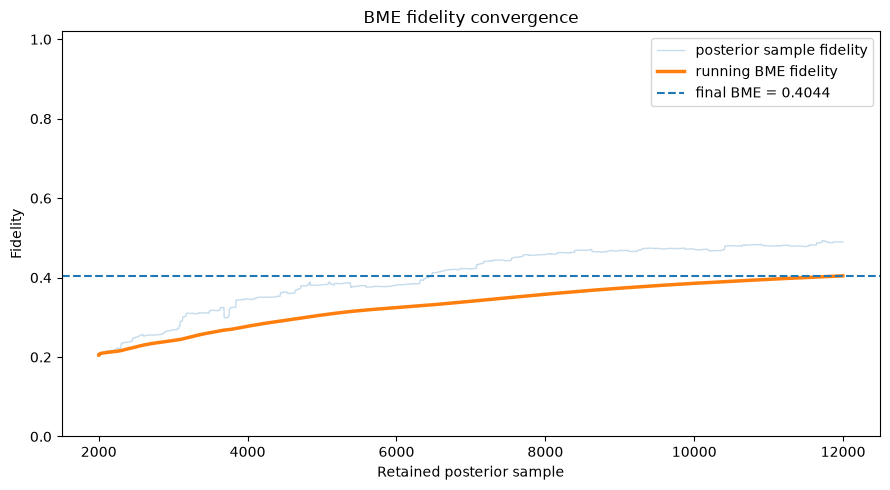

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    info["iterations"],
    info["sample_fidelity"],
    alpha=0.25,
    linewidth=1,
    label="posterior sample fidelity",
)
ax.plot(
    info["iterations"],
    info["running_fidelity"],
    linewidth=2.5,
    label="running BME fidelity",
)
ax.axhline(
    F_bme,
    linestyle="--",
    linewidth=1.5,
    label=f"final BME = {F_bme:.4f}",
)

ax.set_xlabel("Retained posterior sample")
ax.set_ylabel("Fidelity")
ax.set_ylim(0, 1.02)
ax.set_title("BME fidelity convergence")
ax.legend()
fig.tight_layout()
plt.show()


## 6. MH diagnostics

In [ ]:
from bme_homodyne.diagnostics import interactive_mh

result = interactive_mh(
    effects=effects,
    counts=counts,
    N_CUTOFF=N_CUTOFF,
    rho_true=rho_true,
)

## 7. Inspect posterior samples

In [ ]:
rho_me = result["rho_me"]
chain = result["chain"]
diag = result["diag"]

In [ ]:
print("Posterior chain shape:", posterior_samples.shape)
print("BME Hermiticity error:",
      np.linalg.norm(rho_me - rho_me.conj().T))
print("BME trace:", np.trace(rho_me))
print("Smallest eigenvalue:", np.min(np.linalg.eigvalsh(rho_me)))


Posterior chain shape: (2000, 20, 20)
BME Hermiticity error: 0.0
BME trace: (0.9999999999999998+0j)
Smallest eigenvalue: 0.0033765468282849795


## 8. Reconstructed Wigner function

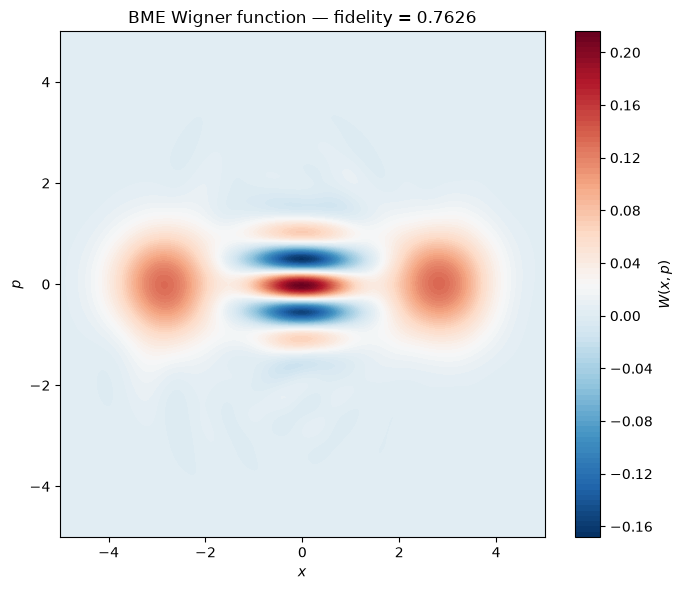

In [ ]:
rho_me_qobj = q.Qobj(rho_me)
F_me = q.fidelity(rho_me_qobj, state)**2
wigner_grid = np.linspace(-5, 5, 200)

W_bme = q.wigner(
    rho_me_qobj,
    wigner_grid,
    wigner_grid,
)

m = np.max(np.abs(W_bme))

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.contourf(
    wigner_grid,
    wigner_grid,
    W_bme,
    levels=100,
    cmap="RdBu_r",
)
fig.colorbar(im, ax=ax, label=r"$W(x,p)$")

ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$p$")
ax.set_title(f"BME Wigner function — fidelity = {F_me:.4f}")

fig.tight_layout()
plt.show()
